# Handwritten Character Recognition using CNN

**Internship Project – AgenticX**

This notebook classifies handwritten digits from the MNIST dataset using a CNN, compares it with a non-neural SVM baseline, visualizes training curves, inspects misclassified examples, and measures inference time.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Load the MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print('Training images:', X_train.shape)
print('Training labels:', y_train.shape)
print('Test images:', X_test.shape)
print('Test labels:', y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## 3. Visualize Sample Images

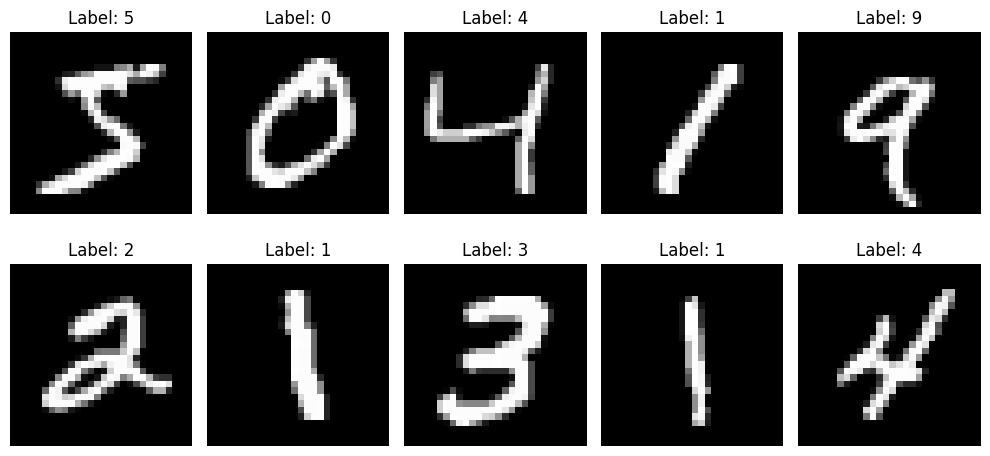

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [4]:
# Normalize pixel values from 0-255 to 0-1
X_train_cnn = X_train.astype('float32') / 255.0
X_test_cnn = X_test.astype('float32') / 255.0

# Add channel dimension for CNN: (samples, 28, 28, 1)
X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_cnn.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(X_train_cnn.shape, X_test_cnn.shape)


(60000, 28, 28, 1) (10000, 28, 28, 1)


## 5. Non-Neural Baseline: SVM

An SVM is used as a traditional machine-learning baseline. It does not use a neural network.

In [5]:
# Use a subset for faster Colab execution while still providing a meaningful baseline.
svm_train_size = 15000
X_svm_train = X_train[:svm_train_size].reshape(svm_train_size, -1).astype('float32') / 255.0
y_svm_train = y_train[:svm_train_size]
X_svm_test = X_test.reshape(len(X_test), -1).astype('float32') / 255.0

svm = SVC(kernel='rbf', C=10, gamma='scale')

start = time.perf_counter()
svm.fit(X_svm_train, y_svm_train)
svm_train_time = time.perf_counter() - start

start = time.perf_counter()
svm_pred = svm.predict(X_svm_test)
svm_inference_time = time.perf_counter() - start

svm_accuracy = accuracy_score(y_test, svm_pred)
print(f'SVM accuracy: {svm_accuracy:.4f}')
print(f'SVM training time: {svm_train_time:.2f} seconds')
print(f'SVM test inference time: {svm_inference_time:.2f} seconds')


SVM accuracy: 0.9728
SVM training time: 21.03 seconds
SVM test inference time: 30.46 seconds


## 6. Build the CNN Model

In [6]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the CNN

In [7]:
start = time.perf_counter()

history = cnn.fit(
    X_train_cnn, y_train_cat,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    verbose=1
)

cnn_training_time = time.perf_counter() - start
print(f'CNN training time: {cnn_training_time:.2f} seconds')


Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.9070 - loss: 0.3067 - val_accuracy: 0.9830 - val_loss: 0.0549
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9717 - loss: 0.0951 - val_accuracy: 0.9868 - val_loss: 0.0421
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9789 - loss: 0.0714 - val_accuracy: 0.9885 - val_loss: 0.0388
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9819 - loss: 0.0595 - val_accuracy: 0.9903 - val_loss: 0.0339
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.9846 - loss: 0.0517 - val_accuracy: 0.9895 - val_loss: 0.0311
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9871 - loss: 0.0417 - val_accuracy: 0.9920 - val_loss: 0.0311
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.9887 - loss: 0.0376 - val_accuracy: 0.9912 - val_loss: 0.0333
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9900 - loss: 0.0331 - val_accu

## 8. Training Curves – Accuracy

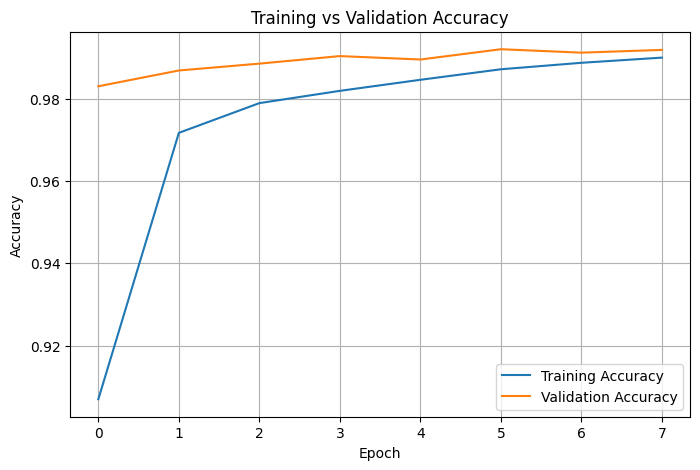

In [8]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 9. Training Curves – Loss

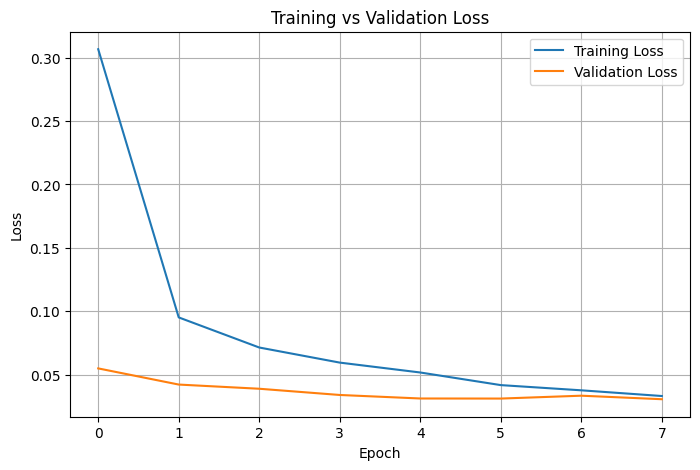

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## 10. Evaluate CNN on Test Data

In [10]:
test_loss, cnn_accuracy = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)

start = time.perf_counter()
cnn_prob = cnn.predict(X_test_cnn, verbose=0)
cnn_inference_time = time.perf_counter() - start
cnn_pred = np.argmax(cnn_prob, axis=1)

print(f'CNN test accuracy: {cnn_accuracy:.4f}')
print(f'CNN test loss: {test_loss:.4f}')
print(f'CNN inference time for {len(X_test_cnn)} images: {cnn_inference_time:.4f} seconds')
print(f'Average CNN inference time per image: {cnn_inference_time/len(X_test_cnn)*1000:.4f} ms')


CNN test accuracy: 0.9909
CNN test loss: 0.0251
CNN inference time for 10000 images: 1.7505 seconds
Average CNN inference time per image: 0.1750 ms


## 11. Confusion Matrix

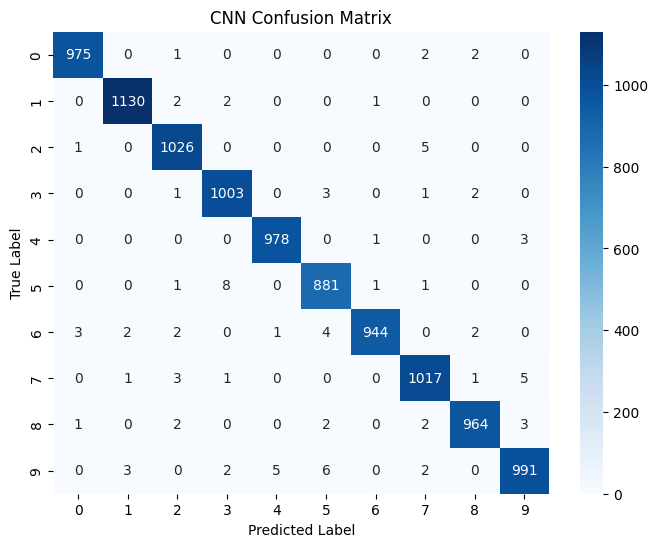

In [11]:
cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.show()


## 12. Classification Report

In [12]:
print(classification_report(y_test, cnn_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9949    0.9949    0.9949       980
           1     0.9947    0.9956    0.9952      1135
           2     0.9884    0.9942    0.9913      1032
           3     0.9872    0.9931    0.9901      1010
           4     0.9939    0.9959    0.9949       982
           5     0.9833    0.9877    0.9855       892
           6     0.9968    0.9854    0.9911       958
           7     0.9874    0.9893    0.9883      1028
           8     0.9928    0.9897    0.9913       974
           9     0.9890    0.9822    0.9856      1009

    accuracy                         0.9909     10000
   macro avg     0.9908    0.9908    0.9908     10000
weighted avg     0.9909    0.9909    0.9909     10000



## 13. Inspect Misclassified Examples

Number of misclassified test images: 91


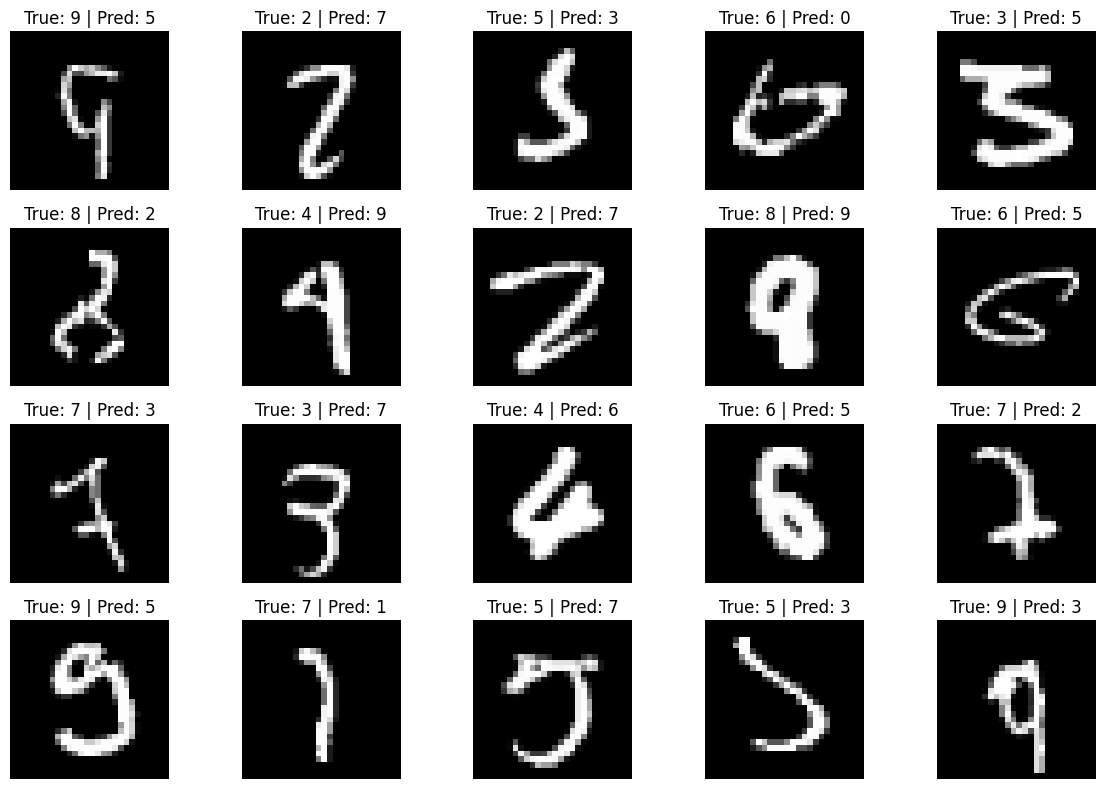

In [13]:
wrong_indices = np.where(cnn_pred != y_test)[0]
print('Number of misclassified test images:', len(wrong_indices))

plt.figure(figsize=(12,8))
for j, idx in enumerate(wrong_indices[:20]):
    plt.subplot(4,5,j+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'True: {y_test[idx]} | Pred: {cnn_pred[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


### Misclassification Discussion

The incorrectly classified samples are typically ambiguous or unusually written digits. Some digits have similar shapes, strokes, or incomplete boundaries, which can make classification difficult even for a well-trained CNN. The displayed examples should be inspected to identify the most common visual patterns behind the errors.

## 14. CNN vs SVM Comparison

In [14]:
print('===== MODEL COMPARISON =====')
print(f'SVM accuracy : {svm_accuracy:.4f}')
print(f'CNN accuracy : {cnn_accuracy:.4f}')
print(f'CNN improvement over SVM: {(cnn_accuracy - svm_accuracy)*100:.2f} percentage points')
print()
print(f'SVM inference time (10,000 images): {svm_inference_time:.4f} s')
print(f'CNN inference time (10,000 images): {cnn_inference_time:.4f} s')


===== MODEL COMPARISON =====
SVM accuracy : 0.9728
CNN accuracy : 0.9909
CNN improvement over SVM: 1.81 percentage points

SVM inference time (10,000 images): 30.4586 s
CNN inference time (10,000 images): 1.7505 s


## 15. Conclusion

The CNN successfully learns visual features from handwritten digit images and provides a strong classification performance on the MNIST test set. The SVM serves as a non-neural baseline for comparison. Training and validation curves help assess generalization and possible overfitting, while the misclassified examples reveal the types of handwriting that remain challenging. Inference time is also measured to provide a practical view of deployment performance.

**Important:** Replace the automatically generated numerical results in your final report with the exact values produced by your own Colab run.

## 16. Optional: Save the Trained CNN Model

Run this cell if you want to keep the trained model.

In [15]:
cnn.save('handwritten_digit_cnn.keras')
print('Model saved as handwritten_digit_cnn.keras')


Model saved as handwritten_digit_cnn.keras
